In [254]:
import pandas as pd

df = pd.read_csv('/Users/gauravdubey/Happy_peoples_.csv')
# df.head()
# df.shape
# df.columns
# df.dtypes
# df.info()
# df.describe()
# df.isnull().sum()

In [255]:
df['Actually_Happy'].value_counts()

Actually_Happy
Yes    68
No     32
Name: count, dtype: int64

In [256]:
df.groupby('Actually_Happy')['Happiness_Level'].mean()

Actually_Happy
No     4.825000
Yes    7.463235
Name: Happiness_Level, dtype: float64

In [257]:
df['Main_Reason_For_Happiness'].value_counts()

Main_Reason_For_Happiness
Sense of purpose            17
Spiritual satisfaction      15
Inner peace                 12
Relationship problems       11
Work stress                  8
Personal growth              6
Good health                  6
Career satisfaction          5
Lack of sleep                5
Financial stability          4
Uncertainty about future     4
Academic pressure            3
Balanced life                2
Supportive relationships     1
Financial pressure           1
Name: count, dtype: int64

In [258]:
df.groupby('Actually_Happy')['Main_Reason_For_Happiness'].value_counts()

Actually_Happy  Main_Reason_For_Happiness
No              Relationship problems        11
                Work stress                   8
                Lack of sleep                 5
                Uncertainty about future      4
                Academic pressure             3
                Financial pressure            1
Yes             Sense of purpose             17
                Spiritual satisfaction       15
                Inner peace                  12
                Good health                   6
                Personal growth               6
                Career satisfaction           5
                Financial stability           4
                Balanced life                 2
                Supportive relationships      1
Name: count, dtype: int64

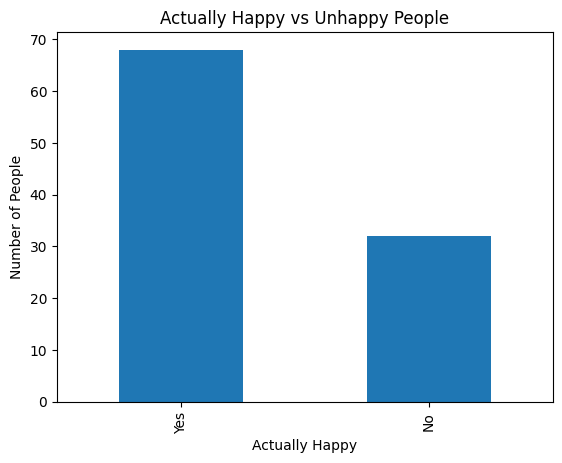

In [259]:
import matplotlib.pyplot as plt

df['Actually_Happy'].value_counts().plot(kind='bar')
plt.xlabel("Actually Happy")
plt.ylabel("Number of People")
plt.title("Actually Happy vs Unhappy People")

plt.show()

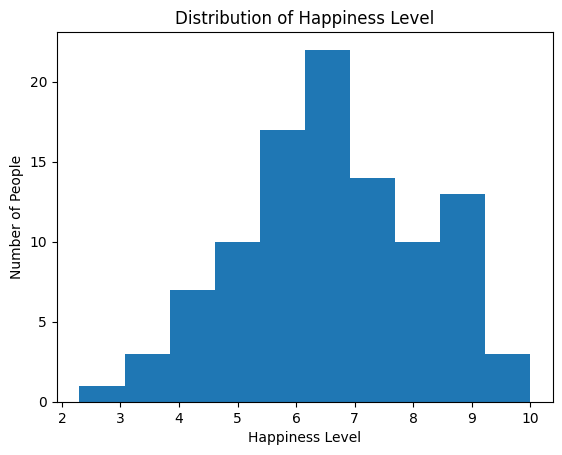

In [260]:
plt.hist(df['Happiness_Level'],bins=10)
plt.xlabel("Happiness Level")
plt.ylabel("Number of People")
plt.title("Distribution of Happiness Level")

plt.show()

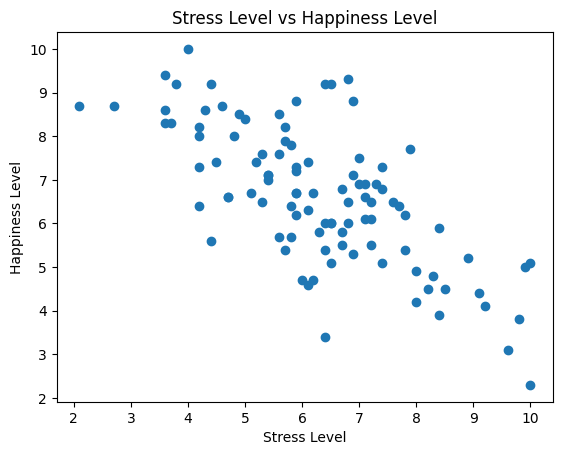

In [261]:
plt.scatter(df['Stress_Level'],df['Happiness_Level'])
plt.xlabel("Stress Level")
plt.ylabel("Happiness Level")
plt.title("Stress Level vs Happiness Level")

plt.show()

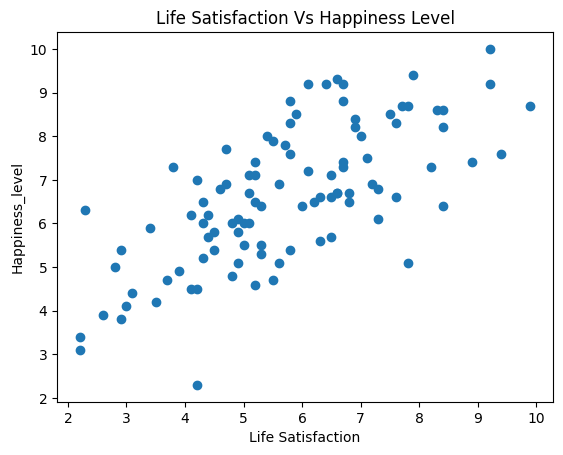

In [262]:
plt.scatter(df['Life_Satisfaction'],df['Happiness_Level'])
plt.xlabel('Life Satisfaction')
plt.ylabel('Happiness_level')
plt.title('Life Satisfaction Vs Happiness Level')
plt.show()

In [263]:
corr = df.corr(numeric_only=True)

print(
    corr["Happiness_Level"]
    .sort_values(ascending=False)
)

Happiness_Level      1.000000
Life_Satisfaction    0.695904
Meditation_Hours     0.413742
Social_Time_Hours    0.227432
Age                  0.006761
Exercise_Hours      -0.010665
Family_Time_Hours   -0.012554
Person_ID           -0.082469
Sleep_Hours         -0.084948
Work_Hours          -0.092645
Stress_Level        -0.695906
Name: Happiness_Level, dtype: float64


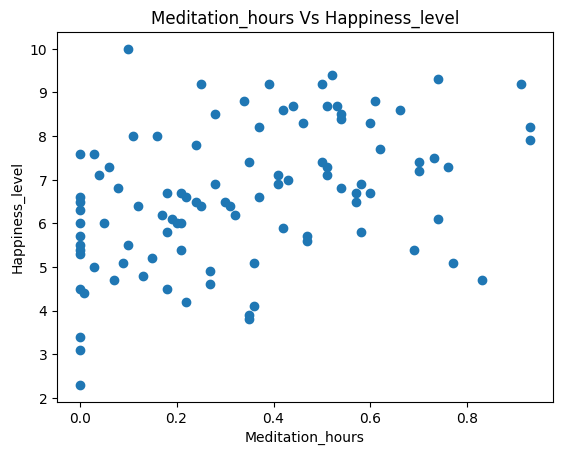

In [264]:
plt.scatter(df['Meditation_Hours'],df['Happiness_Level'])
plt.xlabel('Meditation_hours')
plt.ylabel('Happiness_level')
plt.title('Meditation_hours Vs Happiness_level')
plt.show()

In [265]:
y = df['Actually_Happy']
print(df.columns)

Index(['Person_ID', 'Age', 'Job', 'Work_Hours', 'Sleep_Hours', 'Wake_Up_Time',
       'Exercise_Hours', 'Family_Time_Hours', 'Social_Time_Hours',
       'Meditation_Hours', 'Stress_Level', 'Life_Satisfaction',
       'Happiness_Level', 'Actually_Happy', 'Main_Reason_For_Happiness'],
      dtype='object')


In [266]:
features = [
    "Age",
    "Job",
    "Work_Hours",
    "Sleep_Hours",
    "Wake_Up_Time",
    "Exercise_Hours",
    "Family_Time_Hours",
    "Social_Time_Hours",
    "Meditation_Hours",
    "Stress_Level",
    "Life_Satisfaction"
]

In [267]:
X = df[features]
y = df['Actually_Happy']
print(X.head())
print(y.head())

   Age             Job  Work_Hours  Sleep_Hours Wake_Up_Time  Exercise_Hours  \
0   56           Nurse         6.3     7.418902        06:45             1.2   
1   20  Business Owner         6.8     5.949006        06:30             0.0   
2   59           Nurse         8.3     7.981761        05:15             0.0   
3   28          Doctor         7.6     8.131000        07:00             1.0   
4   44          Doctor         6.4     7.024196        07:15             1.1   

   Family_Time_Hours  Social_Time_Hours  Meditation_Hours  Stress_Level  \
0                1.3                1.3              0.37           4.2   
1                2.9                1.8              0.18           6.2   
2                4.1                2.1              0.52           3.6   
3                2.0                1.7              0.35           4.5   
4                1.0                0.5              0.07           6.0   

   Life_Satisfaction  
0                6.9  
1                5.1  

In [268]:
print(X.dtypes)

Age                    int64
Job                   object
Work_Hours           float64
Sleep_Hours          float64
Wake_Up_Time          object
Exercise_Hours       float64
Family_Time_Hours    float64
Social_Time_Hours    float64
Meditation_Hours     float64
Stress_Level         float64
Life_Satisfaction    float64
dtype: object


In [269]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,
                                                 random_state=42,
                                                 stratify=y)

In [270]:
numeric_features = [
    "Age",
    "Work_Hours",
    "Sleep_Hours",
    "Exercise_Hours",
    "Family_Time_Hours",
    "Social_Time_Hours",
    "Meditation_Hours",
    "Stress_Level",
    "Life_Satisfaction"
]

categorical_features = [
    "Job",
    "Wake_Up_Time"
]

In [271]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([('STD',StandardScaler(),numeric_features),
                                  ('OHE',OneHotEncoder(sparse_output = False,handle_unknown ='ignore'),categorical_features)])

preprocessor.fit_transform(X_train,y_train)

array([[ 0.27456588, -1.10456691, -0.23885044, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.22581773, -0.30180689,  0.49250697, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.79343052, -0.73406228,  0.64060852, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.59020854,  1.30371314,  0.18046298, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.31229517, -0.17830535,  0.68404806, ...,  0.        ,
         0.        ,  0.        ],
       [-0.15782133, -0.73406228,  0.04140461, ...,  0.        ,
         0.        ,  0.        ]], shape=(80, 37))

In [272]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [273]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        C=1.0
    ))
])

In [274]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [275]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [276]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 6  0]
 [ 0 14]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         6
         Yes       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [277]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.7  0.7  0.85 0.65 0.85]
Mean CV Accuracy: 0.75


In [278]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.7  0.7  0.85 0.65 0.85]
Mean CV Accuracy: 0.75


In [279]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_scores)
print("Random Forest Mean CV Accuracy:", rf_scores.mean())

Random Forest CV Scores: [0.8  0.65 0.85 0.7  0.8 ]
Random Forest Mean CV Accuracy: 0.76


In [280]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Test Accuracy:", rf_model.score(X_test, y_test))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Test Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         6
         Yes       0.88      1.00      0.93        14

    accuracy                           0.90        20
   macro avg       0.94      0.83      0.87        20
weighted avg       0.91      0.90      0.89        20



In [293]:
import joblib

joblib.dump(rf_model, "happiness_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [281]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

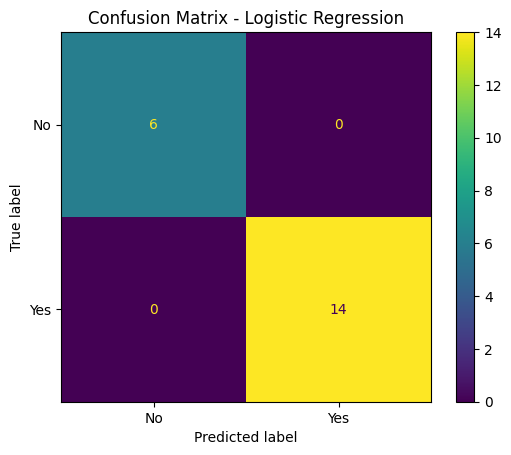

In [282]:
cm = confusion_matrix(y_test,y_pred,labels= ['No','Yes'])

display = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ['No','Yes'])

display.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [283]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         6
         Yes       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [284]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "Age",
    "Work_Hours",
    "Sleep_Hours",
    "Exercise_Hours",
    "Family_Time_Hours",
    "Social_Time_Hours",
    "Meditation_Hours",
    "Stress_Level",
    "Life_Satisfaction"
]

categorical_features = [
    "Job",
    "Wake_Up_Time"
]

preprocessor_nn = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features)
    ]
)

In [285]:
X_train_nn = preprocessor_nn.fit_transform(X_train)
X_test_nn = preprocessor_nn.transform(X_test)

print("Training shape:", X_train_nn.shape)
print("Testing shape:", X_test_nn.shape)

Training shape: (80, 37)
Testing shape: (20, 37)


In [286]:
y_train_nn = (y_train == "Yes").astype(int)
y_test_nn = (y_test == "Yes").astype(int)

In [287]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras)

2.21.0
<module 'tensorflow.keras' from '/Users/gauravdubey/.pyenv/versions/3.10.14/lib/python3.10/site-packages/keras/_tf_keras/keras/__init__.py'>


In [288]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn_model.summary()

/Users/gauravdubey/.pyenv/versions/3.10.14/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761 (6.88 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)

In [289]:
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [290]:
history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)
print(history)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7031 - loss: 0.6231 - val_accuracy: 0.5625 - val_loss: 0.6127
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.5890 - val_accuracy: 0.6250 - val_loss: 0.5947
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5629 - val_accuracy: 0.6250 - val_loss: 0.5806
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5412 - val_accuracy: 0.6250 - val_loss: 0.5652
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5228 - val_accuracy: 0.6250 - val_loss: 0.5518
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7656 - loss: 0.5043 - val_accuracy: 0.6250 - val_loss: 0.5369
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7656 - loss: 0.4876 - val_accuracy: 0.6250 - val_loss: 0.5220
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7812 - loss: 0.4710 - val_accuracy: 0.6875 - val_loss: 0.5098
Epoch 9

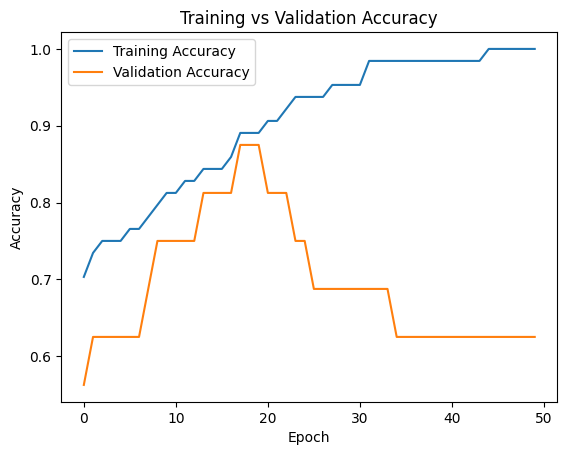

In [291]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

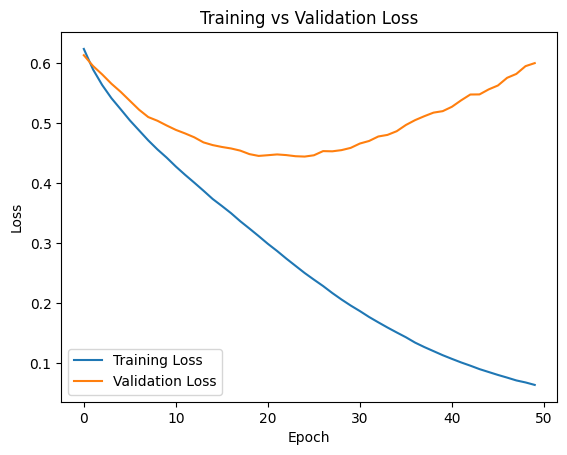

In [292]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()